In [1]:
#%load_ext autoreload
#%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Автоматический подбор элементов дизайна на основе визуального представления

In [2]:
from tqdm import tqdm
from PIL import Image
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.gridspec import GridSpec
#
from img2vec_pytorch import Img2Vec
#
import ultralytics
from ultralytics import YOLO
#
from ultralytics.cfg import get_cfg

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.is_available()}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'count: {torch.cuda.device_count()}')
    print(f'index: {torch.cuda.current_device()}')
    print(f'name: {torch.cuda.get_device_name(0)}')
else:
    print('Nvidia GPU отсутствует или PyTorch не установлен для CUDA')

GPU: True
CUDA version: 12.6
count: 1
index: 0
name: NVIDIA GeForce RTX 4060


In [5]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'data', 'ImageSearch')
print(data_dir)
print()
print('В ней находятся:')
print(os.listdir(data_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch

В ней находятся:
['dataset', 'user_img']


In [6]:
db_dir = os.path.join(data_dir, 'dataset')
print(db_dir)
print()
print('В ней находятся:')
print(os.listdir(db_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\dataset

В ней находятся:
['data.csv', 'images']


In [7]:
db_images_dir = os.path.join(db_dir, 'images')
print(db_images_dir)
print()
print('В ней находятся:')
print(os.listdir(db_images_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\dataset\images

В ней находятся:
['chair1.png', 'chair2.png', 'chair3.png', 'couch1.jpg', 'couch2.png', 'couch3.png', 'cup1.jpg', 'cup2.jpg', 'cup3.png']


## 1 Рассчитываем эмбеддинги для всего набора данных

In [8]:
# Инициализируем класс Img2Vec для рассчета эмбеддингов
img2vec = Img2Vec(
    model='resnet50',
    layer_output_size=2048,
    #cuda=False
    cuda=True
)

# resnet50   2048
# alexnet    4096
# vgg        4096
# densenet   1024

In [9]:
# Читаем 'csv' файл с базой данных изображений
# и помещаем его в Pandas DataFrame
path_to_data = os.path.join(db_dir, 'data.csv')
df = pd.read_csv(path_to_data, sep=';')
#
#df.head(10)

In [10]:
# Извлекаем столбец с названиями изображений и конвертируем его в список
imgs_file_names = df['image_filename'].to_list()
#
print(imgs_file_names)

['cup1.jpg', 'cup2.jpg', 'cup3.png', 'chair1.png', 'chair2.png', 'chair3.png', 'couch1.jpg', 'couch2.png', 'couch3.png']


In [11]:
# Подготавливаем пути к изображениям
imgs_file_paths = [os.path.join(db_images_dir, name) for name in imgs_file_names]
#
print(len(imgs_file_paths))

9


In [12]:
# Открываем каждое изображение, конвертируем в RGB и помещаем в список
imgs_opened = [Image.open(name).convert('RGB') for name in imgs_file_paths]
#
print(len(imgs_opened))

9


In [13]:
# Рассчитываем эмбеддинги для всех изображений из набора данных
imgs_embeddings = img2vec.get_vec(imgs_opened)
#
print(imgs_embeddings.shape)
print()
print(imgs_embeddings)

(9, 2048)

[[  0.0036884           0           0 ...           0           0           0]
 [          0           0    0.023779 ...           0           0           0]
 [          0           0     0.12558 ...           0    0.057815           0]
 ...
 [          0           0     0.93594 ...     0.04048           0           0]
 [          0    0.025612      2.3375 ...           0           0           0]
 [          0           0     0.49544 ...           0           0           0]]


In [14]:
# Создаём новый Pandas DataFrame с эмбеддингами,
# где каждый столбик - это одно значение из вектора
df_imgs_embeddings = pd.DataFrame(imgs_embeddings)
#
#df_imgs_embeddings.head(10)

In [15]:
# Объединяем два Pandas DataFrame в один
df_updated = pd.concat([df, df_imgs_embeddings], axis=1)
#
df_updated.head(3)

,image_filename,description,link_to_market,price,0,1,2,3,4,5,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,cup1.jpg,Чайная пара: чашка на 200 мл с блюдцем,https://link_to_market,305,0.003688,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.022452,0.0,0.0,0.017915,0.000000,0.0,0.000000,0.0
1,cup2.jpg,Золотая чайная пара: чашка на 180 мл с блюдцем,https://link_to_market,195,0.000000,0.0,0.023779,0.0,0.020152,0.016166,...,0.0,0.951697,0.000000,0.0,0.0,0.282643,0.012555,0.0,0.000000,0.0
2,cup3.png,Чайная пара из фарфора Lefard Breeze: чашка 25...,https://link_to_market,1350,0.000000,0.0,0.125576,0.0,0.075836,0.028497,...,0.0,0.000000,0.000000,0.0,0.0,0.006523,0.000000,0.0,0.057815,0.0


In [16]:
# Сохраняем обновлённый Pandas DataFrame в 'csv' файл
path_to_data_updated = os.path.join(db_dir, 'data_updated.csv')
#df_updated.to_csv(path_to_data_updated, sep=';', index=False, header=True, encoding='utf-8')

In [17]:
# Читаем обновлённый 'csv' файл с базой данных изображений и помещаем его в Pandas DataFrame
#path_to_data_updated = os.path.join(db_dir, 'data_updated.csv')
#df_updated = pd.read_csv(path_to_data_updated, sep=';')
#df_updated.head(3)

## 2. Раcпознаём объекты на входном изображении

In [18]:
# Подготавливаем одно пользовательское изображение, для которого
# будет осуществлён поиск наиболее похожих из набора данных
input_img_path_name = os.path.join('user_img', 'living_room.jpg')
print(input_img_path_name)
input_img_path = os.path.join(data_dir, input_img_path_name)
print(input_img_path)

user_img\living_room.jpg
E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\user_img\living_room.jpg


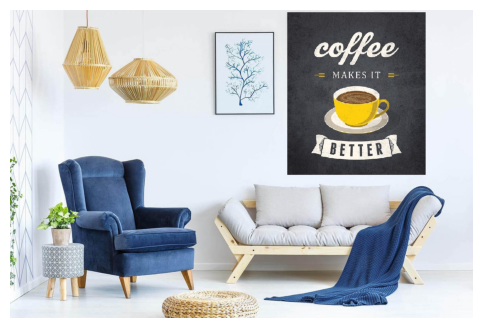

In [19]:
input_img = Image.open(input_img_path).convert('RGB')

fig = plt.figure(figsize=(6, 4), dpi=100)
plt.imshow(input_img)
plt.axis('off')
plt.show()

In [20]:
# Подготавливаем модель
# model = YOLO('yolo11l.pt')
# model = YOLO('yolov10l.pt')
# model = YOLO('yolov9c.pt')
model = YOLO('yolov8l.pt')

# Доступные модели и их отличия:
# https://docs.ultralytics.com/models

100%|█████████████████████████████████████████████████████████████████████████████| 83.7M/83.7M [00:18<00:00, 4.62MB/s]


In [21]:
# Смотрим на доступные аргументы
#config = get_cfg()  
#print(config)

# Детальная информация по аргументам:
# https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
# https://docs.ultralytics.com/modes/predict/#inference-arguments

In [22]:
yolo_result_path = 'YOLO_image_results'

In [23]:
# Запускаем распознавание
results = model.predict(
    source=input_img_path,
    # Сохранять одно изображение со всеми распознанными объектами
    save=True,
    # Сохранять координаты всех распознанных объектов
    save_txt=True,
    # Сохранять распознанные объекты в отдельных файлах
    save_crop=True,
    # Список классов, которые нужно распознать
    classes=[41, 56, 57],  # cup, chair, couch
    # Коэффициент уверенности распознавания
    conf=0.5,
    #device='cpu',  # 'cpu или индекс для GPU, например 0
    device=0,
    # Директория, куда созранять результаты распознавания
    project=yolo_result_path
)


image 1/1 E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\user_img\living_room.jpg: 448x640 1 cup, 1 chair, 1 couch, 32.6ms
Speed: 4.9ms preprocess, 32.6ms inference, 242.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to YOLO_image_results\predict
1 label saved to YOLO_image_results\predict\labels


In [24]:
# Извлекаем путь к директориии с текущим результатом распознавания
save_dir = results[0].save_dir
#
print(save_dir)

YOLO_image_results\predict


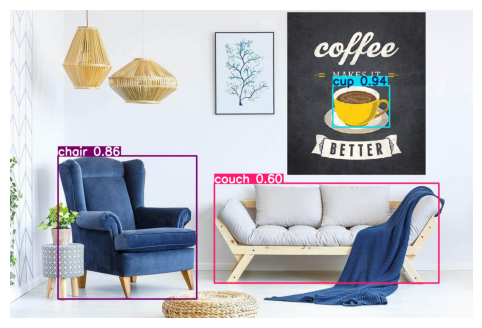

In [25]:
# Подготавливаем путь к распознанному изображению
input_img_deteсted_path = os.path.join(save_dir, 'living_room.jpg')
# Показываем изображение с распознанными объектами
#ImageDisplay(input_img_deteсted_path, width=700)

input_img_deteсted = Image.open(input_img_deteсted_path).convert('RGB')

fig = plt.figure(figsize=(6, 4), dpi=100)
plt.imshow(input_img_deteсted)
plt.axis('off')
plt.show()

In [26]:
# Подготавливаем путь к директории с вырезанными объектами
crops_path = os.path.join(save_dir, 'crops')

# Подготавливаем список с путями ко всем вырезанным объектам
crops_paths_lst = []
crops_filenames_lst = []

# Собираем имена всех файлов вырезанных объектов и помещаем их в список
for root, dirs, files in os.walk(crops_path):
    for file in files:
        crops_paths_lst.append(os.path.join(root, file))
        crops_filenames_lst.append('_in_'.join([root.split(os.sep)[-1], file]))

print(crops_paths_lst)
print()
print(crops_filenames_lst)

['YOLO_image_results\\predict\\crops\\chair\\living_room.jpg', 'YOLO_image_results\\predict\\crops\\couch\\living_room.jpg', 'YOLO_image_results\\predict\\crops\\cup\\living_room.jpg']

['chair_in_living_room.jpg', 'couch_in_living_room.jpg', 'cup_in_living_room.jpg']


## 3. Ищем похожие объекты в базе данных

In [27]:
# Открываем каждый вырезанный объект, конвертируем в RGB и помещаем в список
crops_opened = [Image.open(crop).convert('RGB') for crop in crops_paths_lst]
#
print(len(crops_opened))

3


In [28]:
# Рассчитываем эмбеддинги для всех вырезанных объектов
crops_embeddings = img2vec.get_vec(crops_opened)
#
print(crops_embeddings.shape)
print()
print(crops_embeddings)

(3, 2048)

[[          0           0      2.1966 ...           0           0     0.12932]
 [    0.17556           0      3.0922 ...   0.0036729           0           0]
 [    0.05263           0           0 ...           0           0   0.0078534]]


In [29]:
# Извлекаем столбцы с эмбеддингами
df_data_embeddings = df_updated.iloc[:, 4:]
#
df_data_embeddings.head(30)

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.003688,0.000000,0.000000,0.0,0.000000,0.000000,0.003391,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.022452,0.0,0.0,0.017915,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.023779,0.0,0.020152,0.016166,0.238530,0.022107,0.014134,0.018924,...,0.000000,0.951697,0.000000,0.0,0.0,0.282643,0.012555,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.125576,0.0,0.075836,0.028497,0.559062,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.006523,0.000000,0.000000,0.057815,0.000000
3,0.000000,0.000000,1.111048,0.0,0.000000,0.000000,0.000000,0.015568,0.000000,0.000000,...,0.000000,0.000000,0.390483,0.0,0.0,0.000000,0.000000,0.034841,0.000000,0.000000
4,0.000000,0.002197,2.728914,0.0,0.001734,0.000000,0.212846,0.010012,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.004518,0.014889
5,0.044465,0.000000,4.456269,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.074004,0.0,0.0,0.000000,0.000000,0.042121,0.000000,0.000000
6,0.000000,0.000000,0.935935,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.135598,0.0,0.0,0.000000,0.000000,0.040480,0.000000,0.000000
7,0.000000,0.025612,2.337546,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.020190,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.495437,0.0,0.000000,0.003443,0.000000,0.000000,0.000000,0.000000,...,0.006389,0.000000,0.016678,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [30]:
# Конвертируем столбцы с эмбеддингами в Numpy массив
data_embeddings_np = np.array(df_data_embeddings)
#
print(data_embeddings_np.shape)
print()
print(data_embeddings_np)

(9, 2048)

[[  0.0036884           0           0 ...           0           0           0]
 [          0           0    0.023779 ...           0           0           0]
 [          0           0     0.12558 ...           0    0.057815           0]
 ...
 [          0           0     0.93594 ...     0.04048           0           0]
 [          0    0.025612      2.3375 ...           0           0           0]
 [          0           0     0.49544 ...           0           0           0]]


In [31]:
# Рассчитываем косинусное расстояние между
# пользовательским эмбеддингом и каждым из набора данных
similarities_crops = cosine_similarity(crops_embeddings, data_embeddings_np)
#
print(similarities_crops.shape)
print()
print(similarities_crops)

# Значение косинусного расстояния будет варьироваться от -1 до 1:
#  1 означает полное совпадение
# -1 полное несовпадение

(3, 9)

[[   0.076005     0.11253    0.095146      0.7249     0.66568     0.45843     0.65385     0.73595     0.62773]
 [   0.073639     0.11851     0.12094     0.65351     0.48386     0.48069     0.65394     0.79001     0.55952]
 [    0.51105      0.4471     0.34728    0.084811    0.083672     0.18389    0.043283     0.07885    0.093377]]


In [32]:
# Находим индексы 5-ти наиболее похожих изображений
number = 5
idxs = np.array([np.argsort(arr)[::-1][:number] for arr in similarities_crops])
#
print('Индексы наиболее похожих изображений в порядке убывания:')
print(idxs)

Индексы наиболее похожих изображений в порядке убывания:
[[7 3 4 6 8]
 [7 6 3 8 4]
 [0 1 2 5 8]]


In [33]:
# Извлекаем рассчитанные косинусные расстояния
# в соответствие с индексами наиболее похожих изображений
similarities_crops_found = []

for i, idx in enumerate(idxs):
    similarities_tmp = []
    #print(idx)
    for ii in idx:
        #print(i, ii)
        similarities_tmp.append(similarities_crops[i][ii])
    similarities_crops_found.append(np.array(similarities_tmp))

similarities_crops_found = np.array(similarities_crops_found)
#
print(similarities_crops_found.shape)
print()
print(similarities_crops_found)

(3, 5)

[[    0.73595      0.7249     0.66568     0.65385     0.62773]
 [    0.79001     0.65394     0.65351     0.55952     0.48386]
 [    0.51105      0.4471     0.34728     0.18389    0.093377]]


In [34]:
# Создаём новый Pandas DataFrame для одного вырезанного объекта
# и найденных для него наиболее похожих изображений
#
# idx: индекс вырезанного объекта
def create_similarity_df(idx):
    # Делаем копию Pandas DataFrame извлекаю необходимые строки с наиболее похожими изображениями
    # и оставляем только первые 4 столбца, без эмбеддингов
    tmp_df = df_updated.iloc[idxs[idx], :4].copy()
    
    # Вставляем новые столбцы с названием файла вырезанного объекта
    # и рассчитанными косинусными расстояниями
    tmp_df.insert(loc=0, column='crop_filename', value=crops_filenames_lst[idx])
    tmp_df.insert(loc=2, column='cosine_distance', value=similarities_crops_found[idx])

    return tmp_df 

In [35]:
# Создаём новый Pandas DataFrame для первого вырезанного объекта
tmp_similarity = create_similarity_df(idx=0)
# Смотрим на новый Pandas DataFrame
tmp_similarity.head()

,crop_filename,image_filename,cosine_distance,description,link_to_market,price
7,chair_in_living_room.jpg,couch2.png,0.735950,Диван кушетка Амбер-2 серый,https://link_to_market,12500
3,chair_in_living_room.jpg,chair1.png,0.724904,Кресло для отдыха SCANDICA Дженифер,https://link_to_market,15000
4,chair_in_living_room.jpg,chair2.png,0.665677,Кресло серо-голубое Ракушка,https://link_to_market,55000
6,chair_in_living_room.jpg,couch1.jpg,0.653848,Диван Dandy MINI SE велюр Monolit сталь,https://link_to_market,29900
8,chair_in_living_room.jpg,couch3.png,0.627725,"Угловой диван Аккорд, аккордеон на независимом...",https://link_to_market,85900


In [36]:
# Извлекаем необходимую информацию и помещаем в списки
def show_info(similarity_df):
    print(similarity_df['image_filename'].to_list())
    print()
    print(similarity_df['cosine_distance'].to_list())
    print()
    print(similarity_df['description'].to_list())
    print()
    print(similarity_df['link_to_market'].to_list())
    print()
    print(similarity_df['price'].to_list())

In [37]:
show_info(similarity_df=tmp_similarity)

['couch2.png', 'chair1.png', 'chair2.png', 'couch1.jpg', 'couch3.png']

[0.7359495759010315, 0.7249038219451904, 0.6656773686408997, 0.6538479328155518, 0.6277250647544861]

['Диван кушетка Амбер-2 серый', 'Кресло для отдыха SCANDICA Дженифер', 'Кресло серо-голубое Ракушка', 'Диван Dandy MINI SE велюр Monolit сталь', 'Угловой диван Аккорд, аккордеон на независимом пружинном блоке, 210*200 см']

['https://link_to_market', 'https://link_to_market', 'https://link_to_market', 'https://link_to_market', 'https://link_to_market']

[12500, 15000, 55000, 29900, 85900]


In [38]:
# Создаём функцию, которая строит график для визуализации результатов поиска
def search_results2(test_img, found_imgs, similarities_found, save_path=os.path.join(os.getcwd(), 'search_results.jpg'),
                   test_title='Пользовательское \n изображение', show=True):   
    # Считаем необходимое количество строк
    # для визуализации найденных изображений
    rows = len(found_imgs)

    # Создаём график
    # Подготавливаем график для визуализации изображений
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = fig.add_gridspec(rows, 2)  # строки и 2 столбца

    # Показываем похожие изображения
    # Создаём в правом столбце внутренние графики
    ax = [fig.add_subplot(gs[i, 1]) for i in range(rows)]

    # Визуализируем в правом столбце изображения,
    # которые наиболее похожи на пользовательское,
    # в порядке убывания схожести
    _ = [ax[i].imshow(found_imgs[i]) for i in range(len(ax))]

    # Подписываем в правом столбце каждое изображение,
    # указывая в качестве названия косинусное расстояние
    # между пользовательским эмбеддингом и текущим изображением
    _ = [ax[i].set_title('cos: ' + str(similarities_found[i]), color='0.7') for i in range(len(ax))]

    # Отключаем отображения осей
    _ = [ax[i].set_axis_off() for i in range(len(ax))]

    # Показываем пользовательское изображение
    # Создаём в левом столбце 1 внутренний график, занимая все строки
    ax_big = fig.add_subplot(gs[:, 0])

    # Визуализируем в нём пользовательское изображение
    ax_big.imshow(test_img)

    # Даём название данному внутреннему графику и отключаем отображение осей
    ax_big.set_title(test_title, color='0.6', fontsize=10)
    ax_big.set_axis_off()

    # Даём название всему графику
    fig.suptitle('Найденные наиболее схожие изображения', color='0.4', fontsize=12)
    
    # Настраиваем отступы между внутренними графиками
    plt.tight_layout(h_pad=0.5)
    
    # Сохраняем график
    plt.savefig(save_path, dpi=300)
    
    # Показываем график или отключаем показ
    if show:
        plt.show()
        plt.close()
    else:
        plt.close()

In [39]:
# Подготавливаем и сохраняем Pandas DataFrame для каждого вырезанного объекта
# Визуализируем результаты и сохраняем в файлы

# Итерируем все вырезанные объекты
for idx in range(len(idxs)):
    # Создаём новый Pandas DataFrame для текущего вырезанного объекта
    tmp = create_similarity_df(idx=idx)

    # Сохраняем Pandas DataFrame в 'csv' файл в ту же дирректорию, где находятся текущие результаты
    # с распознанными объектами и даём имя файлу как имя вырезанного объекта
    path_to_tmp = os.path.join(
        save_dir,
        str(crops_filenames_lst[idx].split('.')[0]) + '.csv'
    )
    
    tmp.to_csv(path_to_tmp, sep=';', index=False, header=True, encoding='utf-8')
    
    # Подготавливаем найденные наиболее похожие изображения
    tmp_imgs_paths = [os.path.join(db_dir, 'images', f) for f in tmp['image_filename']]
    
    # Открываем каждое изображение, конвертируем в RGB и помещаем в список
    tmp_imgs_opened = [Image.open(f).convert('RGB') for f in tmp_imgs_paths]
    
    
    # Вызываем функцию для визуализации результатов поиска и сохраняем изображение в ту же дирректорию,
    # где находятся текущие результаты с распознанными объектами
    path_to_searh_results = os.path.join(
        save_dir,
        str(crops_filenames_lst[idx].split('.')[0]) + '_search_reasults.jpg'
    )
    
    search_results2(
        crops_opened[idx],
        tmp_imgs_opened,
        similarities_crops_found[idx],
        save_path=path_to_searh_results,
        test_title='Вырезанный объект',
        show=False
    )

In [40]:
print(f'В директории "{save_dir}" с текущими результатами находятся:')
print(os.listdir(save_dir))

В директории "YOLO_image_results\predict" с текущими результатами находятся:
['chair_in_living_room.csv', 'chair_in_living_room_search_reasults.jpg', 'couch_in_living_room.csv', 'couch_in_living_room_search_reasults.jpg', 'crops', 'cup_in_living_room.csv', 'cup_in_living_room_search_reasults.jpg', 'labels', 'living_room.jpg']


In [41]:
# Читаем 'csv' файл с информацией о результатах поиска и помещаем его в Pandas DataFrame
path_to_crop_data_chair = os.path.join(save_dir, 'chair_in_living_room.csv')
df_crop_chair = pd.read_csv(path_to_crop_data_chair, sep=';')
#
df_crop_chair.head()

,crop_filename,image_filename,cosine_distance,description,link_to_market,price
0,chair_in_living_room.jpg,couch2.png,0.735950,Диван кушетка Амбер-2 серый,https://link_to_market,12500
1,chair_in_living_room.jpg,chair1.png,0.724904,Кресло для отдыха SCANDICA Дженифер,https://link_to_market,15000
2,chair_in_living_room.jpg,chair2.png,0.665677,Кресло серо-голубое Ракушка,https://link_to_market,55000
3,chair_in_living_room.jpg,couch1.jpg,0.653848,Диван Dandy MINI SE велюр Monolit сталь,https://link_to_market,29900
4,chair_in_living_room.jpg,couch3.png,0.627725,"Угловой диван Аккорд, аккордеон на независимом...",https://link_to_market,85900


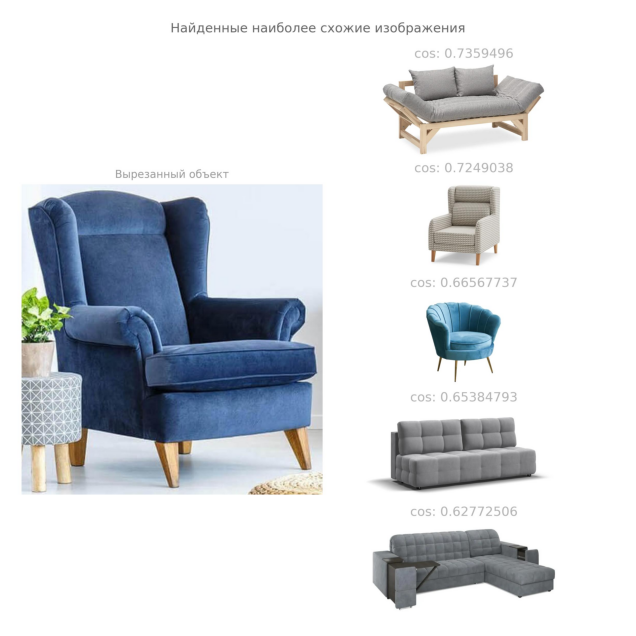

In [42]:
# Подготавливаем путь к сохранённому изображению
# с визуализацией результатов поиска
crop_chair_search_results_path = os.path.join(save_dir, 'chair_in_living_room_search_reasults.jpg')
# Показываем изображение с визуализацией результатов поиска
#ImageDisplay(crop_chair_search_results_path, width=700)

similarity_images = Image.open(crop_chair_search_results_path).convert('RGB')
fig = plt.figure(figsize=(8, 8), dpi=100)
plt.imshow(similarity_images)
plt.axis('off')
plt.show()

In [43]:
# Читаем 'csv' файл с информацией о результатах поиска и помещаем его в Pandas DataFrame
path_to_crop_data_couch = os.path.join(save_dir, 'couch_in_living_room.csv')
df_crop_couch = pd.read_csv(path_to_crop_data_couch, sep=';')
#
df_crop_couch.head()

,crop_filename,image_filename,cosine_distance,description,link_to_market,price
0,couch_in_living_room.jpg,couch2.png,0.790009,Диван кушетка Амбер-2 серый,https://link_to_market,12500
1,couch_in_living_room.jpg,couch1.jpg,0.653936,Диван Dandy MINI SE велюр Monolit сталь,https://link_to_market,29900
2,couch_in_living_room.jpg,chair1.png,0.653514,Кресло для отдыха SCANDICA Дженифер,https://link_to_market,15000
3,couch_in_living_room.jpg,couch3.png,0.559525,"Угловой диван Аккорд, аккордеон на независимом...",https://link_to_market,85900
4,couch_in_living_room.jpg,chair2.png,0.483860,Кресло серо-голубое Ракушка,https://link_to_market,55000


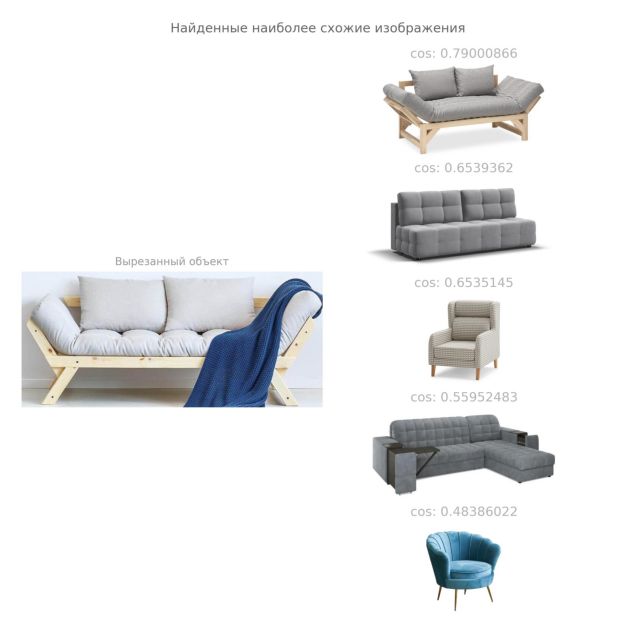

In [44]:
# Подготавливаем путь к сохранённому изображению с визуализацией результатов поиска
crop_couch_search_results_path = os.path.join(save_dir, 'couch_in_living_room_search_reasults.jpg')
# Показываем изображение с визуализацией результатов поиска
#ImageDisplay(crop_couch_search_results_path, width=700)

similarity_images = Image.open(crop_couch_search_results_path).convert('RGB')
fig = plt.figure(figsize=(8, 8), dpi=100)
plt.imshow(similarity_images)
plt.axis('off')
plt.show()

In [45]:
# Читаем 'csv' файл с информацией о результатах поиска и помещаем его в Pandas DataFrame
path_to_crop_data_cup = os.path.join(save_dir, 'cup_in_living_room.csv')
df_crop_cup = pd.read_csv(path_to_crop_data_cup, sep=';')
#
df_crop_cup.head()

,crop_filename,image_filename,cosine_distance,description,link_to_market,price
0,cup_in_living_room.jpg,cup1.jpg,0.511055,Чайная пара: чашка на 200 мл с блюдцем,https://link_to_market,305
1,cup_in_living_room.jpg,cup2.jpg,0.447102,Золотая чайная пара: чашка на 180 мл с блюдцем,https://link_to_market,195
2,cup_in_living_room.jpg,cup3.png,0.347277,Чайная пара из фарфора Lefard Breeze: чашка 25...,https://link_to_market,1350
3,cup_in_living_room.jpg,chair3.png,0.183886,Кресло Поэнг. Каркас черно-коричневый с желтой...,https://link_to_market,16500
4,cup_in_living_room.jpg,couch3.png,0.093377,"Угловой диван Аккорд, аккордеон на независимом...",https://link_to_market,85900


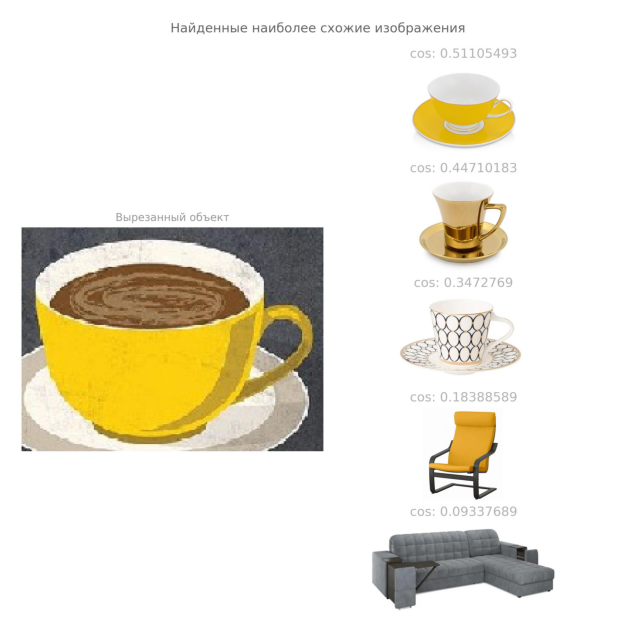

In [46]:
# Подготавливаем путь к сохранённому изображению
# с визуализацией результатов поиска
crop_cup_search_results_path = os.path.join(save_dir, 'cup_in_living_room_search_reasults.jpg')
# Показываем изображение с визуализацией результатов поиска
#ImageDisplay(crop_cup_search_results_path, width=700)

similarity_images = Image.open(crop_cup_search_results_path).convert('RGB')
fig = plt.figure(figsize=(8, 8), dpi=100)
plt.imshow(similarity_images)
plt.axis('off')
plt.show()